<a href="https://colab.research.google.com/github/DhaviRodrigues/Projeto_PISI3_2026/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Primeiras linhas ---


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,...,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,7/15/2010,825532764,148,False,160000000,...,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,11/5/2014,701729206,169,False,165000000,...,en,Interstellar,The adventures of a group of explorers who mak...,140.241,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,7/16/2008,1004558444,152,False,185000000,...,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,12/15/2009,2923706026,162,False,237000000,...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,4/25/2012,1518815515,143,False,220000000,...,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."



--- Resumo Estatístico ---


,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,9.515550e+05,951555.000000,951555.000000,9.515550e+05,951555.000000,9.515550e+05,951555.000000
mean,7.387631e+05,2.095499,22.505769,8.321393e+05,43.545278,3.193111e+05,1.337594
std,4.253503e+05,3.091203,347.993982,2.029706e+07,56.876750,5.530042e+06,7.742745
min,2.000000e+00,0.000000,0.000000,-1.200000e+01,-28.000000,0.000000e+00,0.000000
25%,3.636305e+05,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.600000
50%,7.861260e+05,0.000000,0.000000,0.000000e+00,19.000000,0.000000e+00,0.600000
75%,1.136542e+06,5.000000,1.000000,0.000000e+00,85.000000,0.000000e+00,0.989000
max,1.411040e+06,10.000000,34495.000000,5.000000e+09,14400.000000,1.000000e+09,2994.357000


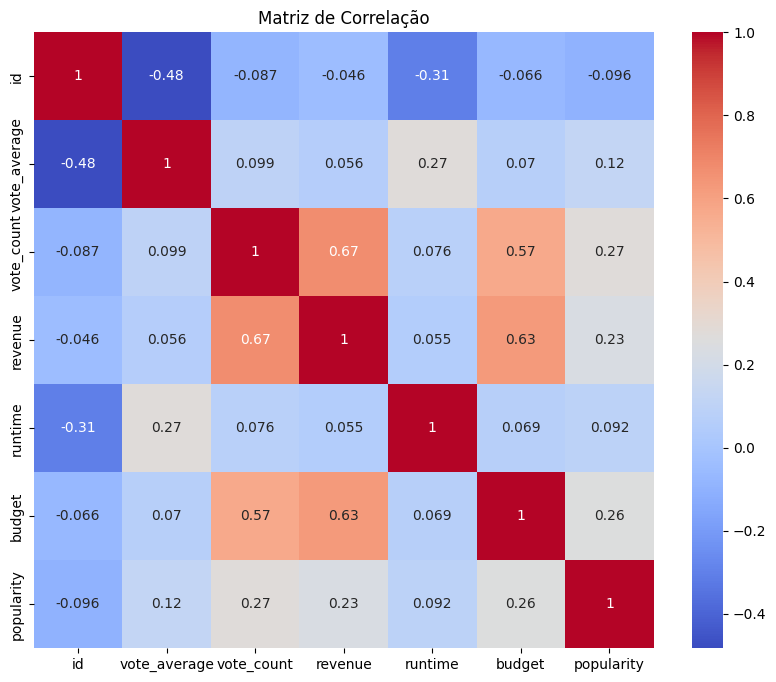

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Corrigindo para ler arquivo Parquet
file_path = '/Imdb_Movie_Dataset.parquet'
try:
    df = pd.read_parquet(file_path)

    # Visualizando as primeiras linhas e informações básicas
    print("--- Primeiras linhas ---")
    display(df.head())

    print("\n--- Resumo Estatístico ---")
    display(df.describe())

    plt.figure(figsize=(10, 8))
    sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
    plt.title('Matriz de Correlação')
    plt.show()
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    print("Verifique se o caminho do arquivo está correto no painel lateral.")

### Análise de Storytelling: O Poder dos Gêneros

Para contar uma história com os dados, primeiro precisamos expandir a coluna de gêneros, já que um filme pode pertencer a vários ao mesmo tempo.

/tmp/ipykernel_9507/475443639.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma')


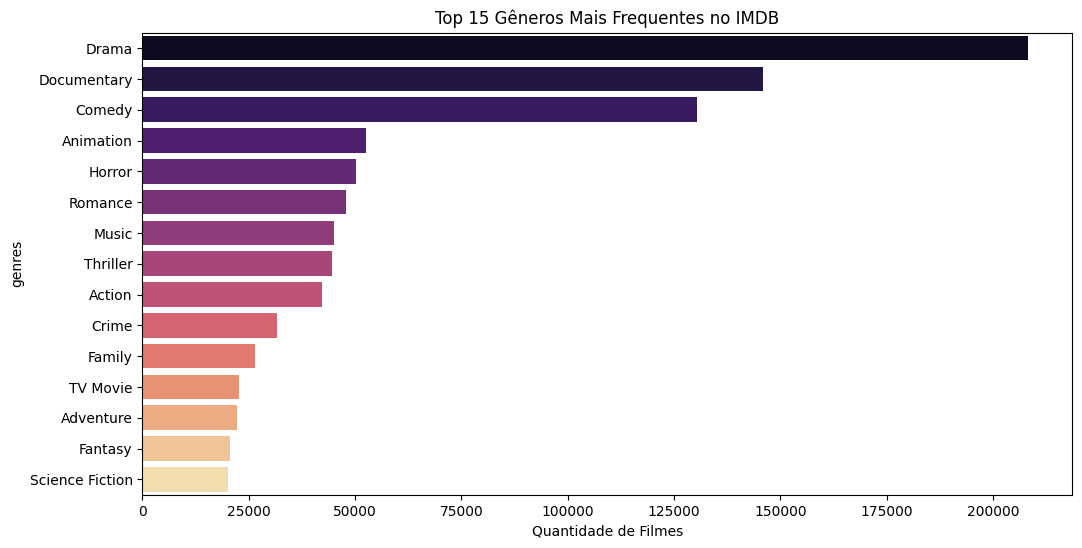

Existem 19 gêneros únicos no dataset.
O gênero mais comum é 'Drama', aparecendo em 208235 títulos.


In [3]:
# Criando uma cópia para não afetar o dataframe original
df_genres = df.copy()

# Transformando a string de gêneros em lista e expandindo para várias linhas
df_genres['genres'] = df_genres['genres'].str.split(', ')
df_exploded = df_genres.explode('genres')

# Removendo valores nulos que possam ter surgido
df_exploded = df_exploded.dropna(subset=['genres'])

plt.figure(figsize=(12, 6))
genre_counts = df_exploded['genres'].value_counts().head(15)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma')
plt.title('Top 15 Gêneros Mais Frequentes no IMDB')
plt.xlabel('Quantidade de Filmes')
plt.show()

print(f"Existem {df_exploded['genres'].nunique()} gêneros únicos no dataset.")
print(f"O gênero mais comum é '{genre_counts.index[0]}', aparecendo em {genre_counts.values[0]} títulos.")

### Probabilidade de Sucesso por Gênero
Define filmes com `vote_average` >= 7.0 como **'Sucesso de Crítica'**. calcula qual a probabilidade de um filme ser um sucesso baseado puramente no seu gênero principal.

/tmp/ipykernel_9507/3662614169.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_analysis['success_probability'] * 100, y=genre_analysis.index, palette='viridis')


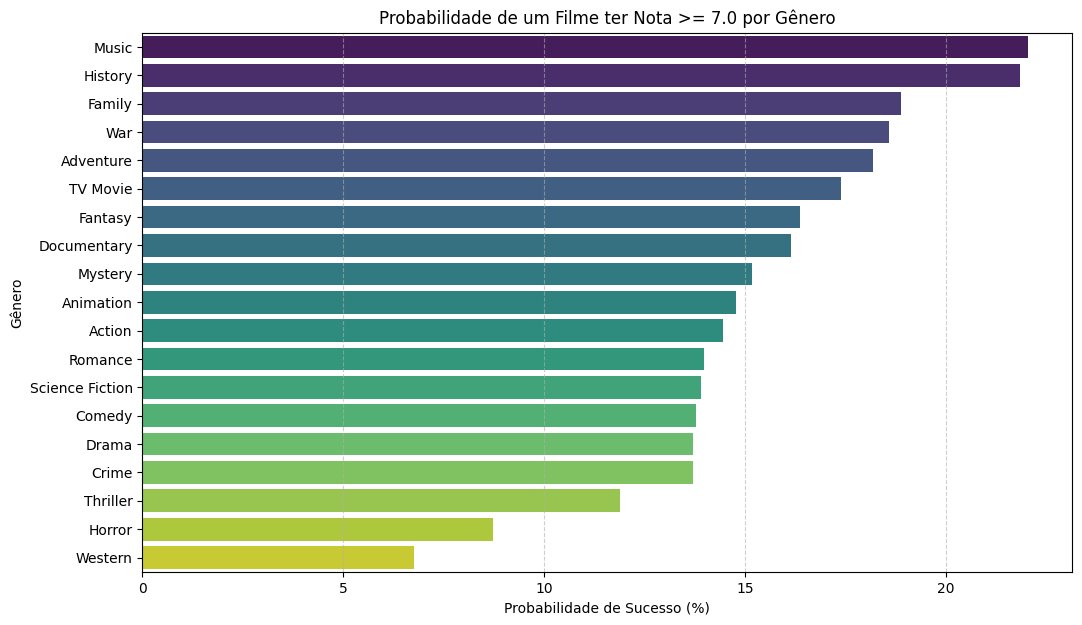

Top 5 Gêneros com maior probabilidade de nota alta:


,success_probability,movie_count
genres,,
Music,0.220506,44992
History,0.218445,15386
Family,0.188811,26365
War,0.185926,9805
Adventure,0.181892,22310


In [4]:
LIMIAR_SUCESSO = 7.0

df_exploded['is_success'] = (df_exploded['vote_average'] >= LIMIAR_SUCESSO).astype(int)

genre_analysis = df_exploded.groupby('genres').agg({
    'is_success': 'mean',
    'vote_average': 'mean',
    'id': 'count'
}).rename(columns={'id': 'movie_count', 'is_success': 'success_probability'})

genre_analysis = genre_analysis[genre_analysis['movie_count'] > 500].sort_values(by='success_probability', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=genre_analysis['success_probability'] * 100, y=genre_analysis.index, palette='viridis')
plt.title(f'Probabilidade de um Filme ter Nota >= {LIMIAR_SUCESSO} por Gênero')
plt.xlabel('Probabilidade de Sucesso (%)')
plt.ylabel('Gênero')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print("Top 5 Gêneros com maior probabilidade de nota alta:")
display(genre_analysis[['success_probability', 'movie_count']].head(5))

### Modelo de Machine Learning: Preditor de Probabilidade de Sucesso

**Objetivo:** Prever a probabilidade de um filme ser 'Bom' (Nota ≥ 7.0) usando apenas seus Gêneros.

**Parâmetros Estruturais:**
*   **Algoritmo:** Regressão Logística (Ideal para probabilidades).
*   **Pré-processamento:** MultiLabelBinarizer para transformar categorias de gêneros em matriz binária.
*   **Ajuste:** Filtramos o dataset para incluir apenas filmes com gêneros válidos.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, accuracy_score

# Volta ao DF original para pegar as listas de gêneros por filme corretamente
df_ml = df.dropna(subset=['genres']).copy()
df_ml['genre_list'] = df_ml['genres'].str.split(', ')

mlb = MultiLabelBinarizer()
X = mlb.fit_transform(df_ml['genre_list'])
y = (df_ml['vote_average'] >= 7.0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia do Modelo: {accuracy:.2%}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Nota < 7', 'Nota >= 7']))

def prever_sucesso(lista_generos):
    generos_encoded = mlb.transform([lista_generos])
    prob = model.predict_proba(generos_encoded)[0][1]
    return f"A chance desse filme ser um sucesso (Nota 7+) é de: {prob:.2%}"

# Exemplo de uso
print("\n--- Simulação de Novo Filme ---")
print("Filme: Drama + Documentário ->", prever_sucesso(['Drama', 'Documentary']))
print("Filme: Terror + Ação ->", prever_sucesso(['Horror', 'Action']))

Acurácia do Modelo: 86.26%

Relatório de Classificação:
              precision    recall  f1-score   support

    Nota < 7       0.86      1.00      0.93    107371
   Nota >= 7       0.50      0.00      0.00     17099

    accuracy                           0.86    124470
   macro avg       0.68      0.50      0.46    124470
weighted avg       0.81      0.86      0.80    124470


--- Simulação de Novo Filme ---
Filme: Drama + Documentário -> A chance desse filme ser um sucesso (Nota 7+) é de: 18.69%
Filme: Terror + Ação -> A chance desse filme ser um sucesso (Nota 7+) é de: 8.60%
